In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
df = pd.read_csv('enhanced_house_price_dataset.csv')
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


# Exploring the Dataset

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Stories,0
Parking,0
Age,0
City,0
Furnishing,0
Main Road,0
Guest Room,0


{'whiskers': [<matplotlib.lines.Line2D at 0x7ee2f81e6e40>,
 'caps': [<matplotlib.lines.Line2D at 0x7ee2f81e77d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ee2f81e5550>],
 'medians': [<matplotlib.lines.Line2D at 0x7ee2f8228260>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ee2f82286b0>],
 'means': []}

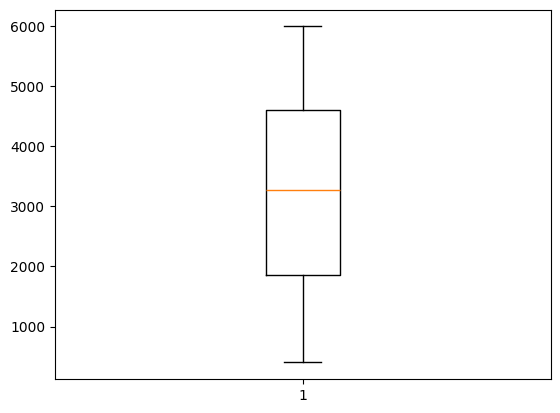

In [ ]:
plt.boxplot(df['Area'])

EDA

<Axes: >

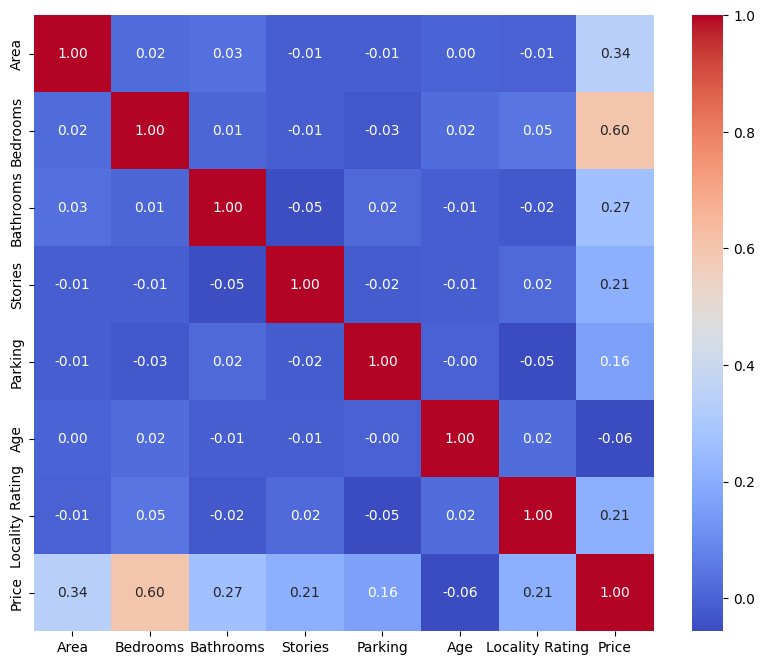

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')

In [ ]:
corr = df.corr()
print(corr['Price'].sort_values(ascending=False))

Price                        1.000000
Bedrooms                     0.600588
Area                         0.339137
Bathrooms                    0.267506
Furnishing                   0.225761
Locality Rating              0.205792
Stories                      0.205615
Air Conditioning             0.186380
Parking                      0.159216
Guest Room                   0.095375
Main Road                    0.094667
Basement                     0.076522
Water Supply_Corporation     0.031587
City_Mumbai                  0.028225
City_Delhi                   0.017442
Preferred Tenant_Bachelor    0.010582
City_Kolkata                 0.009593
Water Supply_Borewell        0.003908
City_Hyderabad               0.001234
Preferred Tenant_Company    -0.002229
City_Pune                   -0.002261
Preferred Tenant_Family     -0.008706
City_Bangalore              -0.009419
Water Supply_Both           -0.035278
City_Chennai                -0.048470
Age                         -0.056614
Name: Price,

# Data Preprocessing

1. Encoding

2. Scaling

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = ['Furnishing','Main Road','Guest Room','Basement','Air Conditioning']
encoder = OrdinalEncoder(categories=[
    ['Unfurnished','Semi-Furnished','Furnished'],
    ['No','Yes'],
    ['No','Yes'],
    ['No','Yes'],
    ['No','Yes']
])
df[oe] = encoder.fit_transform(df[oe]).astype(int)

In [ ]:
cols = ['City','Water Supply','Preferred Tenant']
df = pd.get_dummies(df,columns=cols,dtype=int)

In [ ]:
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Furnishing,Main Road,Guest Room,Basement,...,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Water Supply_Borewell,Water Supply_Both,Water Supply_Corporation,Preferred Tenant_Bachelor,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,1,1,1,1,...,0,0,0,1,0,1,0,0,1,0
1,5790,2,1,1,1,7,0,1,1,1,...,0,1,0,0,0,1,0,1,0,0
2,5626,5,2,3,0,15,1,0,1,1,...,0,0,0,0,0,0,1,0,1,0
3,5591,1,1,1,1,47,2,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,4172,5,1,1,1,44,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0
1996,4803,4,2,1,1,8,2,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1997,5855,5,2,3,0,6,2,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1998,2369,3,3,2,2,15,2,1,0,1,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
print(df.T.duplicated())

Area                         False
Bedrooms                     False
Bathrooms                    False
Stories                      False
Parking                      False
Age                          False
Furnishing                   False
Main Road                    False
Guest Room                   False
Basement                     False
Air Conditioning             False
Locality Rating              False
Price                        False
City_Bangalore               False
City_Chennai                 False
City_Delhi                   False
City_Hyderabad               False
City_Kolkata                 False
City_Mumbai                  False
City_Pune                    False
Water Supply_Borewell        False
Water Supply_Both            False
Water Supply_Corporation     False
Preferred Tenant_Bachelor    False
Preferred Tenant_Company     False
Preferred Tenant_Family      False
dtype: bool


In [ ]:
df['Age'].describe()

,Age
count,2000.000000
mean,24.008500
std,14.319076
min,0.000000
25%,12.000000
50%,24.000000
75%,36.000000
max,49.000000


In [ ]:
X = df.drop('Price',axis=1)
Y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
cols_to_scale = ['Area','Bedrooms','Bathrooms','Stories','Age','Locality Rating']
scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
print(X_train[cols_to_scale].head())

         Area  Bedrooms  Bathrooms  Stories       Age  Locality Rating
968  0.289187       0.0        0.0      1.0  0.306122         0.888889
240  0.321895       1.0        1.0      0.5  0.163265         0.555556
819  0.742627       0.5        1.0      0.5  0.142857         0.777778
692  0.496515       0.0        0.5      1.0  0.836735         0.333333
420  0.132082       1.0        1.0      0.0  0.918367         1.000000


In [ ]:
X_train[cols_to_scale][['Bedrooms']].describe()

,Bedrooms
count,1600.000000
mean,0.516875
std,0.355027
min,0.000000
25%,0.250000
50%,0.500000
75%,0.750000
max,1.000000


In [ ]:
X_train['Locality Rating'].describe()

,Locality Rating
count,1600.000000
mean,0.485139
std,0.315366
min,0.000000
25%,0.222222
50%,0.444444
75%,0.777778
max,1.000000


In [ ]:
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Furnishing,Main Road,Guest Room,Basement,...,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Water Supply_Borewell,Water Supply_Both,Water Supply_Corporation,Preferred Tenant_Bachelor,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,1,1,1,1,...,0,0,0,1,0,1,0,0,1,0
1,5790,2,1,1,1,7,0,1,1,1,...,0,1,0,0,0,1,0,1,0,0
2,5626,5,2,3,0,15,1,0,1,1,...,0,0,0,0,0,0,1,0,1,0
3,5591,1,1,1,1,47,2,1,0,1,...,0,0,0,0,1,0,0,0,1,0
4,4172,5,1,1,1,44,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0
1996,4803,4,2,1,1,8,2,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1997,5855,5,2,3,0,6,2,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1998,2369,3,3,2,2,15,2,1,0,1,...,0,0,0,0,0,1,0,0,0,1


# Model Building

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train,Y_train)

LinearRegression()

In [ ]:
X_test

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Furnishing,Main Road,Guest Room,Basement,...,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Water Supply_Borewell,Water Supply_Both,Water Supply_Corporation,Preferred Tenant_Bachelor,Preferred Tenant_Company,Preferred Tenant_Family
1860,0.161037,0.00,1.0,1.0,2,0.183673,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
353,0.717248,0.25,1.0,0.5,2,0.673469,0,1,1,1,...,1,0,0,0,0,0,1,0,0,1
1333,0.749240,0.75,0.0,0.5,0,0.938776,2,0,1,1,...,1,0,0,0,1,0,0,1,0,0
905,0.234316,0.00,1.0,0.0,1,0.632653,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
1289,0.388561,0.00,0.5,1.0,2,0.734694,2,0,0,0,...,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,0.368007,0.50,0.5,0.5,1,0.938776,2,1,1,0,...,0,0,0,0,0,1,0,0,1,0
1284,0.568186,1.00,0.5,1.0,2,0.836735,2,0,1,1,...,0,0,0,0,0,0,1,0,0,1
1739,0.020554,0.00,0.0,0.5,2,0.000000,2,1,0,0,...,0,0,0,0,0,0,1,1,0,0
261,0.803932,1.00,1.0,0.0,2,0.653061,2,1,0,1,...,0,1,0,0,0,1,0,0,1,0


In [ ]:
y_predict = LR.predict(X_test)

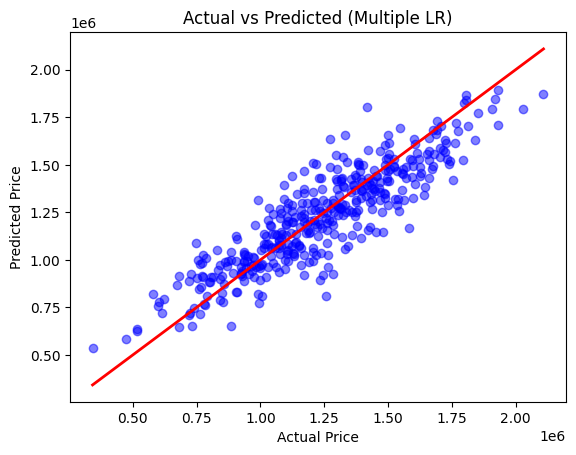

In [ ]:
plt.scatter(Y_test, y_predict, color='blue', alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Multiple LR)")
plt.show()

In [ ]:
y_predict

array([ 986650.08960554, 1380785.93256165, 1377612.26445063,
        808459.60121103, 1000503.03328301, 1128570.20306364,
       1389540.45423192, 1266130.1535696 ,  768295.25970387,
       1661973.15640835, 1396180.51592125, 1181457.727955  ,
       1299333.25034325, 1235719.2678613 , 1287835.06818086,
       1027257.03924675, 1050467.95389485, 1412854.53173169,
        626160.60167066, 1365460.32531792, 1263963.35685841,
        760135.51955511, 1254024.92600372, 1027668.85707505,
        989800.99746311,  967357.35154731,  988889.99920285,
       1024239.62587206, 1342628.1200333 ,  997834.77351079,
       1842646.51672925, 1433043.75534435, 1294299.89140136,
       1091576.69776348, 1021201.67914596, 1155149.81342902,
        847920.34557231, 1365654.12715754, 1173901.07156171,
       1165694.88323491, 1154960.70527585, 1410361.79121415,
       1098700.27817753,  983213.31541231,  961229.11538524,
       1496236.26920221, 1029112.91727855, 1450757.4481967 ,
       1264428.41201468,

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error , root_mean_squared_error
r2_score = r2_score(Y_test,y_predict)
print("R2_Score : " , r2_score)
mse = mean_squared_error(Y_test,y_predict)
print("MSE : " , mse)
mae = mean_absolute_error(Y_test,y_predict)
print("MAE : " , mae)
rmse = root_mean_squared_error(Y_test,y_predict)
print("RMSE : " , rmse)

R2_Score :  0.7775261417077477
MSE :  20165469519.349655
MAE :  111901.16382488629
RMSE :  142005.17426963587


Normal Residuals

In [ ]:
residual = Y_test - y_predict
residual

,Price
1860,-50583.089606
353,-52944.932562
1333,58525.735549
905,450077.398789
1289,-113738.033283
...,...
965,200895.951327
1284,47803.114632
1739,185390.867996
261,107465.036437


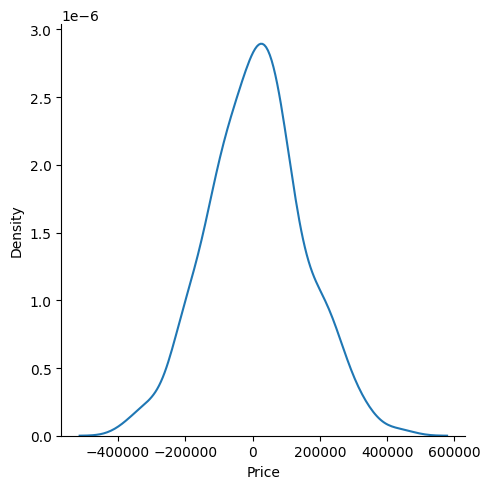

In [ ]:
#using kde to check it is normally distributed
sns.displot(residual,kind='kde')

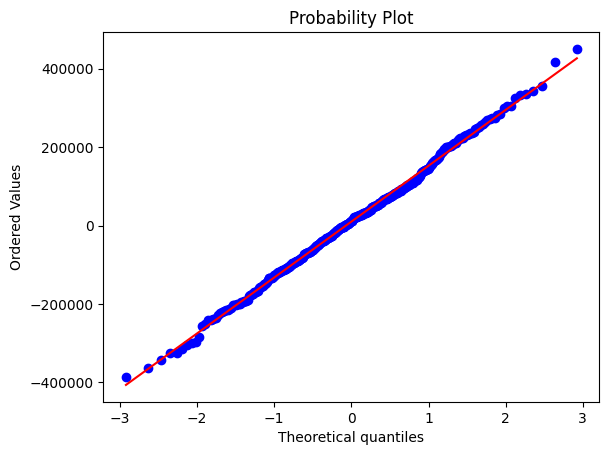

In [ ]:
#using QO Plot
import scipy as sp
sp.stats.probplot(residual, dist="norm", plot=plt)
plt.show()

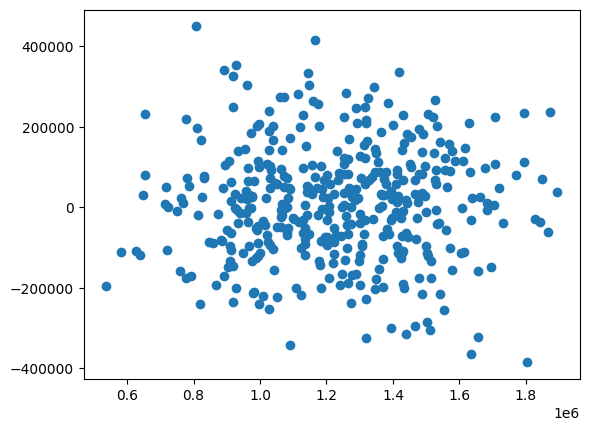

In [ ]:
plt.scatter(y_predict,residual) `1

No Autocollineaity

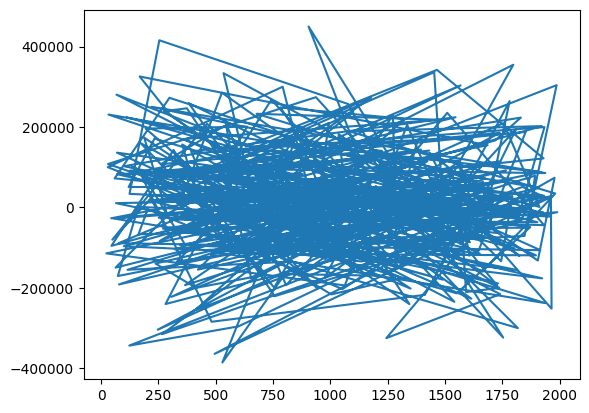

In [ ]:
plt.plot(residual)

In [ ]:
train_score = LR.score(X_train, Y_train)
test_score  = LR.score(X_test, Y_test)
print(f"Train R²: {train_score:.4f}")
print(f"Test R² : {test_score:.4f}")

Train R²: 0.7437
Test R² : 0.7775


In [ ]:
b = LR.coef_
b

array([ 3.28647874e+05,  4.96690574e+05,  1.82345532e+05,  1.68030283e+05,
        6.91263404e+04, -8.30625326e+04,  8.22233110e+04,  5.54573822e+04,
        5.33722153e+04,  5.40133093e+04,  9.03619507e+04,  1.82437402e+05,
       -5.24303358e+01,  7.20872723e+03, -4.20653542e+03,  9.50756188e+03,
       -2.92246118e+03,  2.70915468e+03, -1.22440168e+04,  8.00525688e+03,
       -1.17454434e+04,  3.74018653e+03,  1.13107102e+02, -3.32916696e+03,
        3.21605986e+03])